In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from astropy.table import Table, join, vstack
from astropy.io import fits, ascii
import pickle
from PyAstronomy import pyasl
from time import sleep
from tqdm.notebook import tqdm
import warnings
import bottleneck as bn
from scipy import stats
warnings.filterwarnings("ignore")

In [2]:
# plotting parameters
plt.rc('axes', labelsize=12)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'

paper_params = {
        'text.usetex' : True,
        'font.size'   : 10,
       #'font.family' : 'lmodern',
        'figure.dpi'  : 200
        }
plt.rcParams.update(paper_params)


In [3]:
def split_surf_file(surf_file):
    """
    from file string, extract
    model name,
    metallicity, 
    AGB mass
    inital mass
    final mass
    """
    model_name = surf_file.split('/')[-1][12:]
    metalZ = model_name.split('_')[-1][1:]
    AGB_mass = model_name.split('_')[-2][3:] #(model_name.split('_')[-2][3:4]+'.'+model_name.split('_')[-2][5:6])
    init_mass = (model_name.split('_')[0][1]+'.'+model_name.split('_')[0][3:5])
    final_mass = (model_name.split('_')[1][1]+'.'+model_name.split('_')[1][3:5])
    #if AGB_mass < init_mass: 
    #    return None
    return metalZ,AGB_mass,init_mass,final_mass

In [4]:
# or just get the WD masses directly from FRUITY, dont worry about some IM-FM relation. 
FRUITY_WDs = np.loadtxt('FRUITY_WD_masses.txt',skiprows=0,dtype=float).T

def get_WD_mass_from_FRUITY(m_agb,FeH):
    return FRUITY_WDs[np.where(np.isclose(FRUITY_WDs.T[0],FeH,rtol=7.5e-2,atol=7.5e-2))[0][0]][np.where(FRUITY_WDs[0] == m_agb)[0][0]]

In [7]:
# retrieve white dwarf masses for the grid from FRUITY
model_grid_mw = []
for ma,z in zip(model_grid_ma,model_grid_Z):
    #print(ma,z)
    m_solar = np.round(np.log10(z / 0.0142), decimals=2)
    #print(m_solar)
    model_grid_mw.append(get_WD_mass_from_FRUITY(ma,m_solar))
    
model_grid_mw = np.array(model_grid_mw)

In [8]:
# what does full model grid look like?
list_model_files = np.loadtxt('list_plot_files',dtype=str)
model_grid_Z = []
model_grid_mi = []
model_grid_mf = []
model_grid_ma = []

for file in list_model_files:
    file = file.split('/')[2]
    #print(file)
    model_grid_Z.append(float('0.'+file.split('_')[-1][1:]))
    model_grid_mi.append(float(file.split('_')[1][1:2]+'.'+file.split('_')[1][3:]))
    model_grid_mf.append(float(file.split('_')[2][1:2]+'.'+file.split('_')[2][3:]))
    model_grid_ma.append(float(file.split('_')[3][3:4]+'.'+file.split('_')[3][5:]))
    #print(model_grid_Z,model_grid_mi,model_grid_mf,model_grid_ma)
    if np.isclose(float(model_grid_mf[-1]) - float(model_grid_mi[-1]),0.0,rtol=1e-2,atol=1e-2):
        print(file)
    
model_grid_Z = np.array(model_grid_Z)
model_grid_mi = np.array(model_grid_mi)
model_grid_mf = np.array(model_grid_mf)
model_grid_ma = np.array(model_grid_ma)

# compute mass ratio
model_grid_q = model_grid_mi / model_grid_ma

# define real and physical parts of the grid
model_grid_q_real = model_grid_q < 1.0001
model_grid_acc_eff = (model_grid_mf[model_grid_q_real] - model_grid_mi[model_grid_q_real]) / (model_grid_ma[model_grid_q_real] - model_grid_mw[model_grid_q_real]) * 100
model_grid_acc_eff_real = model_grid_acc_eff < 100.001

In [11]:
## read in our output data
hist_file = 'master_model_hist_list_mass_limit_weights2.dat'
#hist_types = [float, float, float, float, float, str]
#hist_names = ['name',Z','mAGB','m_init','m_final','FeH','chi','reduced_chi',flag']
hist_data = np.genfromtxt(hist_file,dtype=None,encoding='UTF-8')
hist_data = hist_data[::6]
print(len(hist_data))

249


In [12]:
hist_data[0]

('HE1105+0027', 0.0001, 2., 0.45, 0.95, -2.42, 53.83685111, 5.38368511, 'CEMP-r/s')

In [13]:
def collect_data(data,flag):
    name = []
    z = []
    feh = []
    minit = []
    mfinal = []
    magb = []
    macc = []
    q = []
    mwd = []
    capQ = []
    acc_eff = []
    chi = []
    red_chi = []
    for i in range(len(data)):
        if data[i][-1] == flag:
            if data[i][-3] < 1000:# and data[i][-2] < 10 and data[i][4] < 5.0:
                name.append(data[i][0])
                z.append(np.log10(data[i][1]/0.0142))
                feh.append(data[i][5])
                minit.append(data[i][3])
                mfinal.append(data[i][4])
                magb.append(data[i][2])
                macc.append(data[i][4] - data[i][3])
                q.append(data[i][3] / data[i][2])
                m_wd = get_WD_mass_from_FRUITY(data[i][2],np.log10(data[i][1]/0.0142))
                mwd.append(m_wd)
                capQ.append(m_wd**3 / (data[i][4] + m_wd)**2)
                acc_eff.append((data[i][4] - data[i][3]) / (data[i][2] - m_wd) * 100)
                chi.append(data[i][-3])
                red_chi.append(data[i][-2])
            else: 
                continue
    return name,z,feh,minit,mfinal,magb,macc,q,mwd,capQ,acc_eff,chi,red_chi
## read the data, categorize
cemps_names,cemps_z,cemps_feh,cemps_minit,cemps_mfinal,cemps_magb,cemps_macc,cemps_q,cemps_mwd,cemps_capQ,cemps_acc_eff,cemps_chis,cemps_red_chis = collect_data(hist_data,'CEMP-s')
cempr_names,cempr_z,cempr_feh,cempr_minit,cempr_mfinal,cempr_magb,cempr_macc,cempr_q,cempr_mwd,cempr_capQ,cempr_acc_eff,cempr_chis,cempr_red_chis = collect_data(hist_data,'CEMP-r')
cemprs_names,cemprs_z,cemprs_feh,cemprs_minit,cemprs_mfinal,cemprs_magb,cemprs_macc,cemprs_q,cemprs_mwd,cemprs_capQ,cemprs_acc_eff,cemprs_chis,cemprs_red_chis = collect_data(hist_data,'CEMP-r/s')
cempno_names,cempno_z,cempno_feh,cempno_minit,cempno_mfinal,cempno_magb,cempno_macc,cempno_q,cempno_mwd,cempno_capQ,cempno_acc_eff,cempno_chis,cempno_red_chis = collect_data(hist_data,'CEMP-no')
wba_names,wba_z,wba_feh,wba_minit,wba_mfinal,wba_magb,wba_macc,wba_q,wba_mwd,wba_capQ,wba_acc_eff,wba_chis,wba_red_chis = collect_data(hist_data,'WBa')
sba_names,sba_z,sba_feh,sba_minit,sba_mfinal,sba_magb,sba_macc,sba_q,sba_mwd,sba_capQ,sba_acc_eff,sba_chis,sba_red_chis = collect_data(hist_data,'SBa')
ch_names,ch_z,ch_feh,ch_minit,ch_mfinal,ch_magb,ch_macc,ch_q,ch_mwd,ch_capQ,ch_acc_eff,ch_chis,ch_red_chis = collect_data(hist_data,'CH')
empty_names,empty_z,empty_feh,empty_minit,empty_mfinal,empty_magb,empty_macc,empty_q,empty_mwd,empty_capQ,empty_acc_eff,empty_chis,empty_red_chis = collect_data(hist_data,'empty')
## concat all into some arrays
full_names = np.concatenate([cemps_names,cemprs_names,cempr_names,cempno_names,wba_names,sba_names,ch_names,empty_names])
full_z = np.concatenate([cemps_z,cemprs_z,cempr_z,cempno_z,wba_z,sba_z,ch_z,empty_z])
full_feh = np.concatenate([cemps_feh,cemprs_feh,cempr_feh,cempno_feh,wba_feh,sba_feh,ch_feh,empty_feh])
full_minit = np.concatenate([cemps_minit,cemprs_minit,cempr_minit,cempno_minit,wba_minit,sba_minit,ch_minit,empty_minit])
full_mfinal = np.concatenate([cemps_mfinal,cemprs_mfinal,cempr_mfinal,cempno_mfinal,wba_mfinal,sba_mfinal,ch_mfinal,empty_mfinal])
full_magb = np.concatenate([cemps_magb,cemprs_magb,cempr_magb,cempno_magb,wba_magb,sba_magb,ch_magb,empty_magb])
full_macc = np.concatenate([cemps_macc,cemprs_macc,cempr_macc,cempno_macc,wba_macc,sba_macc,ch_macc,empty_macc])
full_q = np.concatenate([cemps_q,cemprs_q,cempr_q,cempno_q,wba_q,sba_q,ch_q,empty_q])
full_mwd = np.concatenate([cemps_mwd,cemprs_mwd,cempr_mwd,cempno_mwd,wba_mwd,sba_mwd,ch_mwd,empty_mwd])
full_capQ = np.concatenate([cemps_capQ,cemprs_capQ,cempr_capQ,cempno_capQ,wba_capQ,sba_capQ,ch_capQ,empty_capQ])
full_acc_eff = np.concatenate([cemps_acc_eff,cemprs_acc_eff,cempr_acc_eff,cempno_acc_eff,wba_acc_eff,sba_acc_eff,ch_acc_eff,empty_acc_eff])
full_chis = np.concatenate([cemps_chis,cemprs_chis,cempr_chis,cempno_chis,wba_chis,sba_chis,ch_chis,empty_chis])
full_red_chis = np.concatenate([cemps_red_chis,cemprs_red_chis,cempr_red_chis,cempno_red_chis,wba_red_chis,sba_red_chis,ch_red_chis,empty_red_chis])

print('# of stars by category:')
print('CEMP-s',len(cemps_feh));print('CEMP-r/s',len(cemprs_feh));print('CEMP-r',len(cempr_feh));print('CEMP-no',len(cempno_feh));print('CH',len(ch_feh));
print('weak Ba',len(wba_feh));print('strong Ba',len(sba_feh));print('None',len(empty_feh))

# of stars by category:
CEMP-s 43
CEMP-r/s 17
CEMP-r 0
CEMP-no 0
CH 3
weak Ba 82
strong Ba 97
None 7


In [14]:
# empirical accretion efficiency from mass ratios from Liu+ 2017 3D hydro wind simulations
def compute_acc_eta(q_mass_ratio):
    eta_acc = -197.3*q_mass_ratio**5 + 455.5*q_mass_ratio**4 - 355.4*q_mass_ratio**3 + 111.8*q_mass_ratio**2 - 7.410*q_mass_ratio - 0.2649
    return eta_acc
# same for angular momentum j
def compute_acc_ang(q_mass_ratio):
    j_acc = - 2.657*q_mass_ratio**5 + 6.642*q_mass_ratio**4 - 5.810*q_mass_ratio**3 + 2.051*q_mass_ratio**2 - 0.1075*q_mass_ratio + 0.1185
    return j_acc

In [15]:
def linear_eta_acc(mass_ratio):
    return (8.171*mass_ratio - 0.8253)

def linear_ang_mom(mass_ratio):
    return(0.1271*mass_ratio + 0.1178)

In [16]:
# generate theoretical lines in eta_acc and j_s space
test_mass_ratios = np.linspace(0.0001,1.20,1000)
test_linear_eta_acc = []
test_5th_order_eta_acc = []
test_linear_ang_mom = []
test_5th_order_ang_mom = []
for mass_ratio in test_mass_ratios:
    test_linear_eta_acc.append(linear_eta_acc(mass_ratio))
    test_5th_order_eta_acc.append(compute_acc_eta(mass_ratio))
    test_linear_ang_mom.append(linear_ang_mom(mass_ratio))
    test_5th_order_ang_mom.append(compute_acc_ang(mass_ratio))

In [17]:
def density_contours(m1, m2):
    X, Y = np.mgrid[-1:m1.max()+1.00:1000j, -10:m2.max()+20.00:2000j]
    
    print('raveling')
    positions = np.vstack([X.ravel(), Y.ravel()])
    
    print('stacking')
    values = np.vstack([m1, m2])
    
    print('generating kernel...')   
    kernel = stats.gaussian_kde(values)
    
    print('generating density contours...')
    Z = np.reshape(kernel(positions).T, X.shape)
    
    return X, Y, Z

In [18]:
## Create contours for different stellar types -- where do they land in the efficiency diagram?
#Xeta, Yeta, Zeta = density_contours(model_grid_q[model_grid_q_real][model_grid_acc_eff_real],np.array(model_grid_acc_eff[model_grid_acc_eff_real]))
XCmp,YCmp,ZCmp = density_contours(np.concatenate([ch_q,cemps_q]),np.array(np.concatenate([ch_acc_eff,cemps_acc_eff])))
#XCH,YCH,ZCH = density_contours(np.concatenate([ch_q]),np.array(np.concatenate([ch_acc_eff])))
XWBa,YWBa,ZWBa = density_contours(np.concatenate([wba_q]),np.array(np.concatenate([wba_acc_eff])))
XSBa,YSBa,ZSBa = density_contours(np.concatenate([sba_q]),np.array(np.concatenate([sba_acc_eff])))


raveling
stacking
generating kernel...
generating density contours...
raveling
stacking
generating kernel...
generating density contours...
raveling
stacking
generating kernel...
generating density contours...


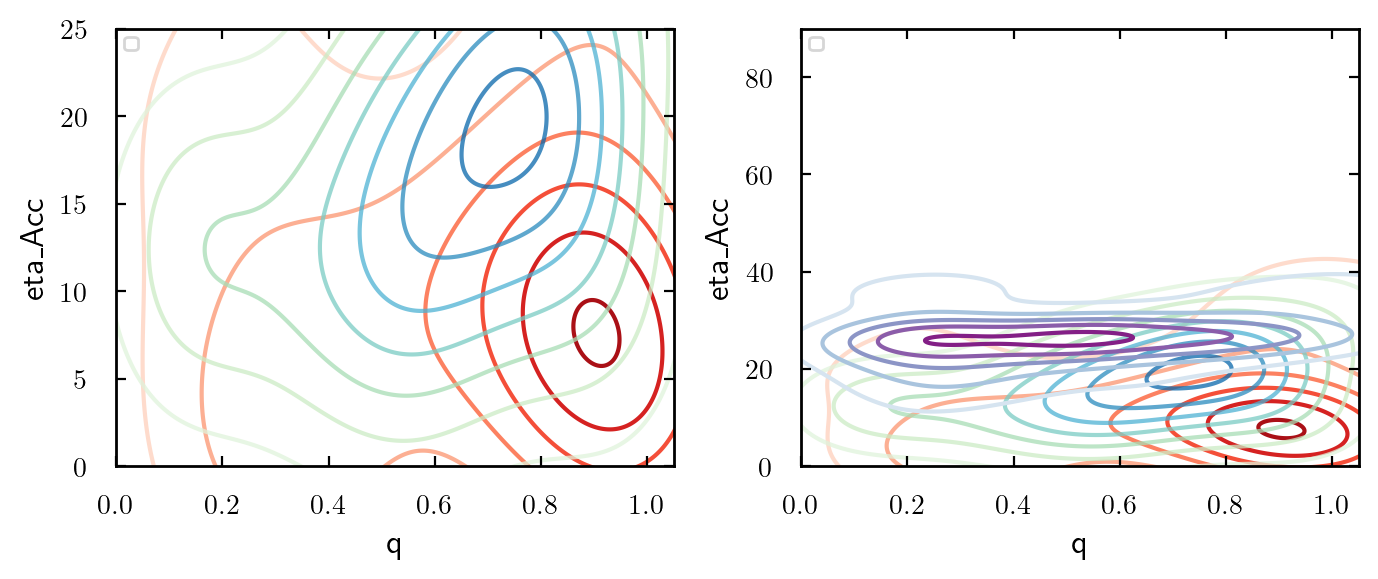

In [19]:
# plot the grid
fig, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(7,3),dpi=200)
ax1.contour(XCmp, YCmp, ZCmp, cmap=plt.cm.Reds,zorder=1)
#ax1.contour(XCH, YCH, ZCH, cmap=plt.cm.YlOrBr,zorder=1)
ax1.contour(XWBa,YWBa,ZWBa, cmap=plt.cm.GnBu,zorder=1,alpha=0.75)
#ax1.contour(XSBa,YSBa,ZSBa, cmap=plt.cm.BuPu,zorder=1,linestyle='dotted')

#ax1.scatter(model_grid_q[model_grid_q_real][model_grid_acc_eff_real],model_grid_acc_eff[model_grid_acc_eff_real],c='grey',alpha=0.10,s=2,label=r'$\rm{Model Grid}$')
#ax1.plot(test_mass_ratios,test_linear_eta_acc,ls='--',color='black',lw=1,label='Wind Theory Linear')
#ax1.plot(test_mass_ratios,test_5th_order_eta_acc,ls=':',color='black',lw=1,label='Wind Theory Non-Linear')
#ax1.scatter(cemps_q,cemps_acc_eff,s=5,alpha=0.30,c='crimson')
#ax1.scatter(ch_q,ch_acc_eff,s=5,alpha=0.30,c='orange')
#ax1.scatter(wba_q,wba_acc_eff,s=5,alpha=0.30,c='cyan')
#ax1.scatter(sba_q,sba_acc_eff,s=5,alpha=0.30,c='blue')
ax1.set_ylim(0,25)
ax1.set_xlim(0,1.05)
ax1.legend(loc='upper left',fontsize=6)
ax1.set_xlabel('q')
ax1.set_ylabel('eta_Acc %')

ax2.contour(XCmp, YCmp, ZCmp, cmap=plt.cm.Reds,zorder=1)
#ax2.contour(XCH, YCH, ZCH, cmap=plt.cm.YlOrBr,zorder=1)
ax2.contour(XWBa,YWBa,ZWBa, cmap=plt.cm.GnBu,zorder=1,alpha=0.75)
ax2.contour(XSBa,YSBa,ZSBa, cmap=plt.cm.BuPu,zorder=1)

#ax2.scatter(model_grid_q[model_grid_q_real][model_grid_acc_eff_real],model_grid_acc_eff[model_grid_acc_eff_real],c='grey',alpha=0.10,s=2,label=r'$\rm{Model Grid}$')
#ax2.plot(test_mass_ratios,test_linear_eta_acc,ls='--',color='black',lw=1,label=r'$\rm{Wind Theory Linear}$')
#ax2.plot(test_mass_ratios,test_5th_order_eta_acc,ls=':',color='black',lw=1,label=r'$\rm{Wind Theory Non-Linear}$')
#ax2.scatter(cemps_q,cemps_acc_eff,s=5,alpha=0.30,c='crimson')
#ax2.scatter(ch_q,ch_acc_eff,s=5,alpha=0.30,c='orange')
#ax2.scatter(wba_q,wba_acc_eff,s=5,alpha=0.30,c='cyan')
#ax2.scatter(sba_q,sba_acc_eff,s=5,alpha=0.30,c='blue')
ax2.set_ylim(0,90)
ax2.set_xlim(0,1.05)
ax2.legend(loc='upper left',fontsize=6)
ax2.set_xlabel('q')
ax2.set_ylabel('eta_Acc %')

fig.tight_layout()